# Options Strategy Practice 02: Long Put

This notebook continues from **Long Call** and studies the **Long Put** strategy using a static expiration model.

Goals:

1. Understand when a Long Put makes or loses money;
2. Calculate payoff, maximum profit, maximum loss, and breakeven;
3. Plot the expiration payoff and P&L curves;
4. Compare the risk profile with a Long Call.

## 1. Understand the Trade

A Long Put gives you the right, but not the obligation, to sell the underlying asset at strike price `K` at expiration. You usually buy a put when you expect the underlying price to fall.

Assumptions:

- Current underlying price: 100
- Strike price `K`: 95
- Premium per share: 2
- Number of contracts: 1
- Shares per contract: 100

The initial cost is `2 × 100 = $200`. If the underlying finishes at or above 95, the put expires worthless and the $200 is lost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

spot = 100
strike = 95
premium = 2
contracts = 1
multiplier = 100

initial_cost = premium * contracts * multiplier
breakeven = strike - premium
max_profit = (strike - premium) * contracts * multiplier

print(f'Initial premium cost: ${initial_cost:,.0f}')
print(f'Breakeven: ${breakeven:.2f}')
print(f'Maximum profit: ${max_profit:,.0f}')

Initial premium cost: $200
Breakeven: $93.00
Maximum profit: $9,300


## 2. Expiration Payoff and P&L Formula

Let the underlying price at expiration be `S_T`:

- Put payoff: `max(K - S_T, 0)`
- Long Put P&L: `max(K - S_T, 0) - premium`

The put becomes more valuable as the underlying falls. Payoff is the option value at expiration; P&L subtracts the premium paid at entry.

In [2]:
def long_put_pnl(spot_at_expiry, strike, premium, multiplier=1, contracts=1):
    '''Return total Long Put P&L at expiration. Prices are per share.'''
    intrinsic_value = np.maximum(strike - np.asarray(spot_at_expiry), 0)
    pnl_per_share = intrinsic_value - premium
    return pnl_per_share * multiplier * contracts

expiry_prices = np.linspace(0, 140, 501)
payoff_per_share = np.maximum(strike - expiry_prices, 0)
pnl = long_put_pnl(expiry_prices, strike, premium, multiplier, contracts)

results = pd.DataFrame({
    'expiry_price': expiry_prices,
    'payoff_per_share': payoff_per_share,
    'total_pnl': pnl,
})
results.head()

,expiry_price,payoff_per_share,total_pnl
0,0.00,95.00,9300.0
1,0.28,94.72,9272.0
2,0.56,94.44,9244.0
3,0.84,94.16,9216.0
4,1.12,93.88,9188.0


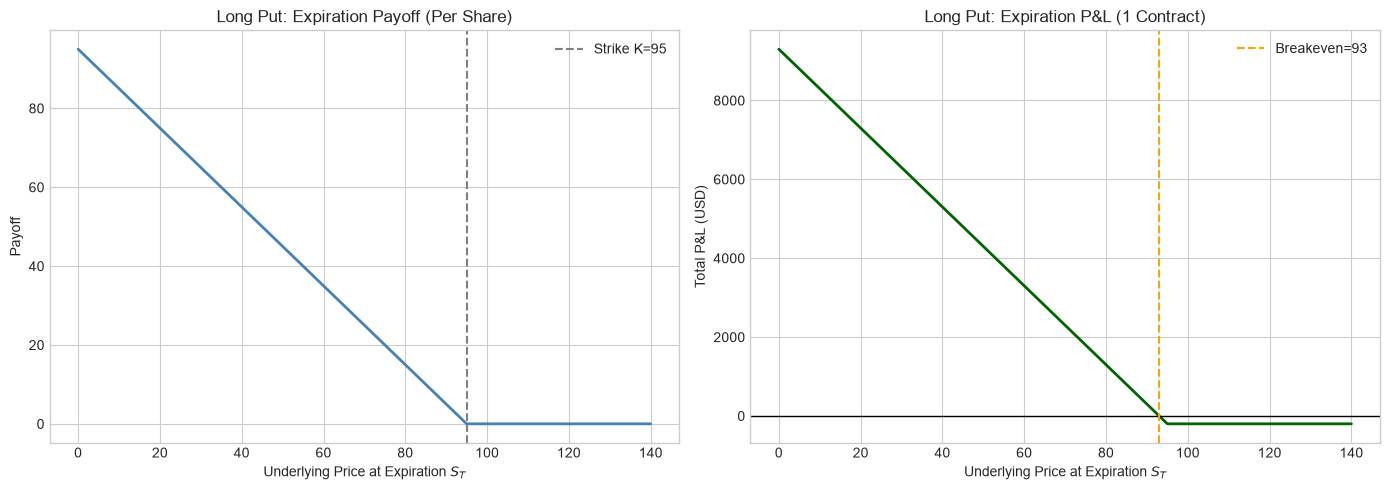

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(expiry_prices, payoff_per_share, color='steelblue', linewidth=2)
axes[0].axvline(strike, color='gray', linestyle='--', label=f'Strike K={strike}')
axes[0].set_title('Long Put: Expiration Payoff (Per Share)')
axes[0].set_xlabel('Underlying Price at Expiration $S_T$')
axes[0].set_ylabel('Payoff')
axes[0].legend()

axes[1].plot(expiry_prices, pnl, color='darkgreen', linewidth=2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(breakeven, color='orange', linestyle='--', label=f'Breakeven={breakeven}')
axes[1].set_title('Long Put: Expiration P&L (1 Contract)')
axes[1].set_xlabel('Underlying Price at Expiration $S_T$')
axes[1].set_ylabel('Total P&L (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Maximum Profit, Maximum Loss, and Breakeven

- **Maximum loss**: `premium × multiplier × contracts` = **$200**.
- **Maximum profit**: approximately `(strike - premium) × multiplier × contracts` = **$9,300**, if the underlying falls to zero.
- **Breakeven**: `strike - premium` = **$93**. Profit begins below 93 at expiration.

Unlike a Long Call, a Long Put's profit is capped because the underlying price cannot fall below zero. This is the static expiration model; before expiration, implied volatility, time decay, and the option's market price also affect trading P&L.

In [4]:
sample_prices = [0, 50, 93, 95, 100, 120]
sample = pd.DataFrame({
    'Underlying Price at Expiration': sample_prices,
    'Total P&L': long_put_pnl(sample_prices, strike, premium, multiplier, contracts)
})

print(f'Maximum Loss: ${initial_cost:,.0f}')
print(f'Maximum Profit: ${max_profit:,.0f}')
print(f'Breakeven: ${breakeven:.2f}')
sample

Maximum Loss: $200
Maximum Profit: $9,300
Breakeven: $93.00


,Underlying Price at Expiration,Total P&L
0,0,9300
1,50,4300
2,93,0
3,95,-200
4,100,-200
5,120,-200


## 4. Compare Long Put with Long Call

The key symmetry is:

- Long Call: benefits from the underlying rising; breakeven is `K + premium`.
- Long Put: benefits from the underlying falling; breakeven is `K - premium`.
- Both have a maximum loss limited to the premium paid.
- Long Call profit is theoretically unlimited; Long Put profit is capped when the underlying reaches zero.

## 5. Exercises

1. Change `strike` to 100. What are the new breakeven and maximum profit?
2. Change `premium` to 5. How do maximum loss and breakeven change?
3. Change `contracts` to 10. Does the curve shape change? What happens to the dollar P&L?
4. For expiration prices 90, 93, 95, and 100, calculate the P&L by hand before running the code.
5. In one sentence, explain why the Long Put P&L becomes more positive when `S_T` decreases.